In [1]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [2]:
# %%
import matplotlib.pyplot as plt
import numpy as np
import ray
import pandas as pd


from mpl_toolkits.mplot3d import Axes3D

from starforge.blackholes.parameters_recover.parameters_recovery import (
    ParametersRecoveryRemote
)

from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)

from starforge.blackholes.accretionrate.blackholesaccretionrate import (
    ParameterAccretionRate
)

from starforge.blackholes.parameters_recover.utils import (
    add_noise_to_data,
    gaussian_sum_from_p,
    make_bounds_for_gaussians,
)

from starforge.blackholes.parameters_recover.schemes import (
    GridParameters
)

In [3]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-19 14:12:27,984	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [4]:
# ============================================================
# GRID
# ============================================================

mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps * 100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

In [5]:
# %%
# ============================================================
# BENCHMARK INITIAL CONDITION
# ============================================================

benchmark_params = np.array([
    3.3e-02,
    8.2e-03,
    5.4e-02,
    1.07e+01,
    1.29e+01,
    1.21e+01,
    6.93e-01,
    1.05e+00,
    7.47e-01
])

initial_condition = gaussian_sum_from_p(
    benchmark_params,
    ln_mbh_grid,
    n_gauss=3
)

In [6]:
# %%
# ============================================================
# PHYSICAL MODEL PARAMETERS
# ============================================================

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)

In [7]:
# ============================================================
# FORWARD SOLVER
# ============================================================

objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [8]:
# %%
# ============================================================
# REFERENCE FINAL BHMF
# ============================================================

reference_outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)

reference_final = reference_outputs.n_final

In [9]:
# ============================================================
# SYNTHETIC OBSERVATION
# ============================================================

noise_level = 0.10

target_data = add_noise_to_data(
    data=reference_final,
    mu=0.0,
    sigma=noise_level,
    rho=0.5,
    alpha=0.5,
    seed=52,
    noise_type='mixed'
)

In [10]:
# %%
# ============================================================
# OPTIMIZATION BOUNDS
# ============================================================

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)

bounds.extend([
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),    # tau_par
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),     # t_q
    (0.01, 0.5),    # b_1
    (0.01, 0.5),    # b_2
])

In [11]:
# %%
recovery = ParametersRecoveryRemote.remote(
    grid_params=grid_params
)

In [12]:
return_components = True

In [ ]:
# %%
# ============================================================
# L-SURFACE COMPUTATION
# ============================================================

alpha_p_values = np.logspace(-2, 1, 5)
alpha_theta_values = np.logspace(-2, 1, 5)

results = []

for alpha_p in alpha_p_values:
    for alpha_theta in alpha_theta_values:

        print(
            f"Running optimization with "
            f"alpha_p={alpha_p:.2e}, "
            f"alpha_theta={alpha_theta:.2e}"
        )

        # ----------------------------------------------------
        # Optimization
        # ----------------------------------------------------

        best = ray.get(
            recovery.optimizer.remote(
                bounds=bounds,
                target_data=target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                n_max=1
            )
        )

        # ----------------------------------------------------
        # Diagnostics
        # ----------------------------------------------------

        diagnostics = ray.get(
            recovery.objective_function.remote(
                np.array(best.x),
                target_data,
                weight_p=alpha_p,
                weight_theta=alpha_theta,
                return_components=True
            )
        )

        results.append({
            "alpha_p": alpha_p,
            "alpha_theta": alpha_theta,
            "objective": diagnostics["objective"],
            "misfit": diagnostics["misfit"],
            "R_p": diagnostics["R_p"],
            "R_theta": diagnostics["R_theta"],
            "best_parameters": np.array(best.x),
        })

Running optimization with alpha_p=1.00e-05, alpha_theta=1.00e-05
(ParametersRecovery pid=556011) Starting optimization ...
(ParametersRecovery pid=556011) Objective value: 1.924344e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 1.546409e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 8.987383e-02 | Context: Minimum detected in annealing process


(ParametersRecovery pid=556011) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=556011)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=556011) Objective value: 6.163679e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 5.785721e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 4.852921e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 4.184846e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 3.977158e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 3.948923e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 3.841047e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 3.259538e-02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 3.259423e-02 | Context: Minimum detected in annealing process
(

(ParametersRecovery pid=556011) /home/eduardo/Projects/starforge2/src/starforge/blackholes/parameters_recover/parameters_recovery.py:202: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=556011)   normalization_model = np.log10(params_array[-n:] + epsilon)
(ParametersRecovery pid=556011) /home/eduardo/Projects/starforge2/src/starforge/blackholes/discreteblackholemf/blackholesmassfunction.py:86: RuntimeWarning: invalid value encountered in log10
(ParametersRecovery pid=556011)   x = log10_m_grid - np.log10(self.accretionrate.params.mbh_par)


Running optimization with alpha_p=1.00e-05, alpha_theta=1.00e-01
(ParametersRecovery pid=556011) Stage 1/1 | Best Objective: 2.017238e-01
(ParametersRecovery pid=556011) Optimization completed | Final Objective: 2.017238e-01
(ParametersRecovery pid=556011) Starting optimization ...
(ParametersRecovery pid=556011) Objective value: 1.050078e+00 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 9.088030e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 7.769659e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 7.651995e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 6.997362e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 6.992224e-01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=556011) Objective value: 6.

In [14]:
# %%
# ============================================================
# SURFACE ARRAYS
# ============================================================

alpha_p_grid = np.array([r["alpha_p"] for r in results])
alpha_theta_grid = np.array([r["alpha_theta"] for r in results])

misfit_grid = np.array([r["misfit"] for r in results])

X = np.log10(alpha_p_grid)
Y = np.log10(alpha_theta_grid)
Z = np.log10(misfit_grid + 1e-15)

# Reshape to structured grid
X = X.reshape(len(alpha_p_values), len(alpha_theta_values))
Y = Y.reshape(len(alpha_p_values), len(alpha_theta_values))
Z = Z.reshape(len(alpha_p_values), len(alpha_theta_values))

(ParametersRecovery pid=556011) Stage 1/1 | Best Objective: 1.061051e+02
(ParametersRecovery pid=556011) Optimization completed | Final Objective: 1.061051e+02


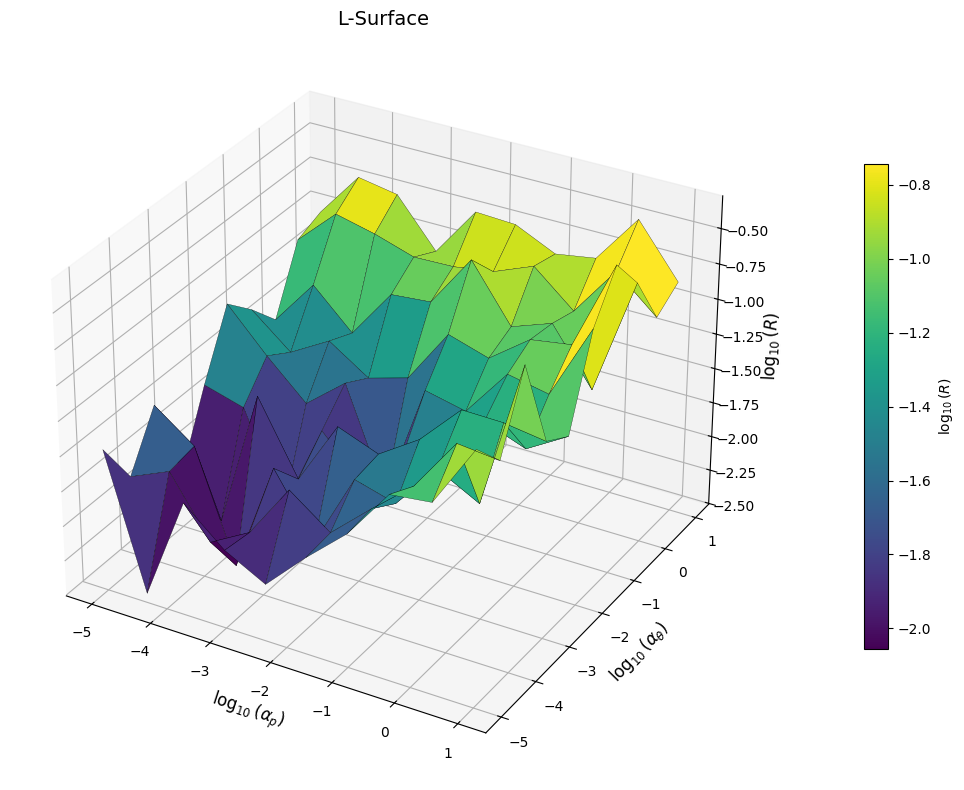

In [15]:
# %%
# ============================================================
# L-SURFACE PLOT
# ============================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.2,
    antialiased=True
)

ax.set_xlabel(r"$\log_{10}(\alpha_p)$", fontsize=12)
ax.set_ylabel(r"$\log_{10}(\alpha_\theta)$", fontsize=12)
ax.set_zlabel(r"$\log_{10}(R)$", fontsize=12)

ax.set_title("L-Surface", fontsize=14)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label=r"$\log_{10}(R)$"
)

plt.tight_layout()
plt.show()

In [16]:
# %%

df = pd.DataFrame(results)

# ------------------------------------------------------------
# Log quantities
# ------------------------------------------------------------

epsilon = 1e-15

df["log_alpha_p"] = np.log10(df["alpha_p"] + epsilon)
df["log_alpha_theta"] = np.log10(df["alpha_theta"] + epsilon)

df["log_R"] = np.log10(df["misfit"] + epsilon)
df["log_R_p"] = np.log10(df["R_p"] + epsilon)
df["log_R_theta"] = np.log10(df["R_theta"] + epsilon)

df["log_J"] = np.log10(df["objective"] + epsilon)

In [17]:
# %%
# ------------------------------------------------------------
# Pareto frontier
# ------------------------------------------------------------

costs = df[
    [
        "misfit",
        "R_p",
        "R_theta",
    ]
].values

n_points = costs.shape[0]

is_pareto = np.ones(n_points, dtype=bool)

for i in range(n_points):

    if not is_pareto[i]:
        continue

    for j in range(n_points):

        if i == j:
            continue

        dominates = (
            np.all(costs[j] <= costs[i]) and
            np.any(costs[j] < costs[i])
        )

        if dominates:

            is_pareto[i] = False
            break

df["pareto"] = is_pareto

print(
    f"Pareto-optimal points: "
    f"{df['pareto'].sum()} / {len(df)}"
)

Pareto-optimal points: 39 / 100


In [18]:
# %%
# ------------------------------------------------------------
# Pareto subset
# ------------------------------------------------------------

pareto_df = (
    df[df["pareto"]]
    .copy()
    .reset_index(drop=False)
)

print(pareto_df[
    [
        "alpha_p",
        "alpha_theta",
        "misfit",
        "R_p",
        "R_theta",
        "objective",
    ]
])

      alpha_p  alpha_theta    misfit       R_p   R_theta   objective
0    0.000010     0.000010  0.032456  7.296130  6.222572    0.032592
1    0.000010     0.464159  0.028207  7.717932  4.468856    2.102543
2    0.000046     0.000010  0.003642  7.425978  6.655526    0.004053
3    0.000046     0.000046  0.019571  7.535965  5.126529    0.020159
4    0.000046     0.000215  0.021127  7.890681  4.993823    0.022569
5    0.000046     0.001000  0.004201  8.195164  6.060904    0.010642
6    0.000046     0.100000  0.026916  7.628460  5.060908    0.533360
7    0.000046     2.154435  0.147159  7.999027  4.086216    8.951016
8    0.000215     0.000046  0.007380  7.414648  6.069119    0.009259
9    0.000215     0.000215  0.003453  7.801369  6.069733    0.006441
10   0.000215     0.004642  0.004599  7.545546  6.272568    0.035339
11   0.000215     0.464159  0.032516  7.817901  4.411178    2.081688
12   0.000215     2.154435  0.125741  7.752354  4.118550    9.000557
13   0.001000     0.000046  0.0106

In [19]:
# %%
# ------------------------------------------------------------
# Stability metric in parameter space
# ------------------------------------------------------------

parameter_matrix = np.vstack(
    pareto_df["best_parameters"].values
)

stability = []

for i in range(len(pareto_df)):

    current = parameter_matrix[i]

    distances = np.linalg.norm(
        parameter_matrix - current,
        axis=1
    )

    distances[i] = np.inf

    nearest_distance = distances.min()

    stability.append(nearest_distance)

pareto_df["stability"] = stability

In [20]:
# %%
# ------------------------------------------------------------
# Normalize objectives
# ------------------------------------------------------------

for column in [
    "misfit",
    "R_p",
    "R_theta",
    "stability",
]:

    cmin = pareto_df[column].min()
    cmax = pareto_df[column].max()

    pareto_df[f"{column}_norm"] = (
        (pareto_df[column] - cmin) /
        (cmax - cmin + 1e-15)
    )

In [21]:
# %%
# ------------------------------------------------------------
# Composite robust score
# ------------------------------------------------------------

w_misfit = 0.50
w_reg_p = 0.20
w_reg_theta = 0.20
w_stability = 0.10

pareto_df["robust_score"] = (
    w_misfit * pareto_df["misfit_norm"] +
    w_reg_p * pareto_df["R_p_norm"] +
    w_reg_theta * pareto_df["R_theta_norm"] -
    w_stability * pareto_df["stability_norm"]
)

best_index = pareto_df["robust_score"].idxmin()

best_row = pareto_df.loc[best_index]

print(best_row[
    [
        "alpha_p",
        "alpha_theta",
        "misfit",
        "R_p",
        "R_theta",
        "objective",
        "stability",
        "robust_score",
    ]
])

alpha_p          2.154435
alpha_theta      0.464159
misfit           0.038934
R_p              6.563126
R_theta          4.587696
objective       16.308179
stability        2.602822
robust_score      0.14859
Name: 34, dtype: object


In [22]:
# %%
# ------------------------------------------------------------
# Recover optimal parameters
# ------------------------------------------------------------

optimal_parameters = best_row["best_parameters"]

print("\nOptimal recovered parameters:\n")

for i, value in enumerate(optimal_parameters):

    print(f"p[{i}] = {value:.6e}")


Optimal recovered parameters:

p[0] = 1.784515e-04
p[1] = 9.859635e-02
p[2] = 9.434157e-02
p[3] = 8.916186e+00
p[4] = 1.026842e+01
p[5] = 1.184254e+01
p[6] = 7.728412e-01
p[7] = 3.339427e-01
p[8] = 5.194058e-01
p[9] = 1.149422e+00
p[10] = 4.246931e+00
p[11] = 4.528310e-01
p[12] = 3.726104e-01
p[13] = 5.684026e-01
p[14] = 2.636487e-02
p[15] = 4.478906e-01


In [23]:
# %%
# ------------------------------------------------------------
# Neighbor analysis around optimum
# ------------------------------------------------------------

pareto_df["distance"] = np.sqrt(
    (
        pareto_df["log_alpha_p"] -
        best_row["log_alpha_p"]
    )**2
    +
    (
        pareto_df["log_alpha_theta"] -
        best_row["log_alpha_theta"]
    )**2
)

neighbors = (
    pareto_df
    .sort_values("distance")
    .head(7)
    .copy()
)

neighbors = neighbors.sort_values(
    by=[
        "log_alpha_p",
        "log_alpha_theta",
    ]
)

print(neighbors[
    [
        "log_alpha_p",
        "log_alpha_theta",
        "log_R",
        "log_R_p",
        "log_R_theta",
        "log_J",
        "stability",
        "robust_score",
    ]
])

    log_alpha_p  log_alpha_theta     log_R   log_R_p  log_R_theta     log_J  \
29    -1.000000        -0.333333 -1.120880  0.883406     0.621211  0.444138   
30    -0.333333         0.333333 -1.067753  0.862266     0.648389  1.115729   
31    -0.333333         1.000000 -0.824840  0.848843     0.630543  1.664061   
34     0.333333        -0.333333 -1.409670  0.817111     0.661595  1.212405   
35     0.333333         0.333333 -0.706957  0.839939     0.608957  1.377580   
37     1.000000         0.333333 -0.953311  0.765773     0.651102  1.832977   
38     1.000000         1.000000 -0.839630  0.787457     0.649927  2.025736   

    stability  robust_score  
29   2.729524      0.301555  
30   3.598055      0.290228  
31   4.187300      0.406738  
34   2.602822      0.148590  
35   3.059003      0.534177  
37   2.320599      0.274758  
38   3.598055      0.347114  


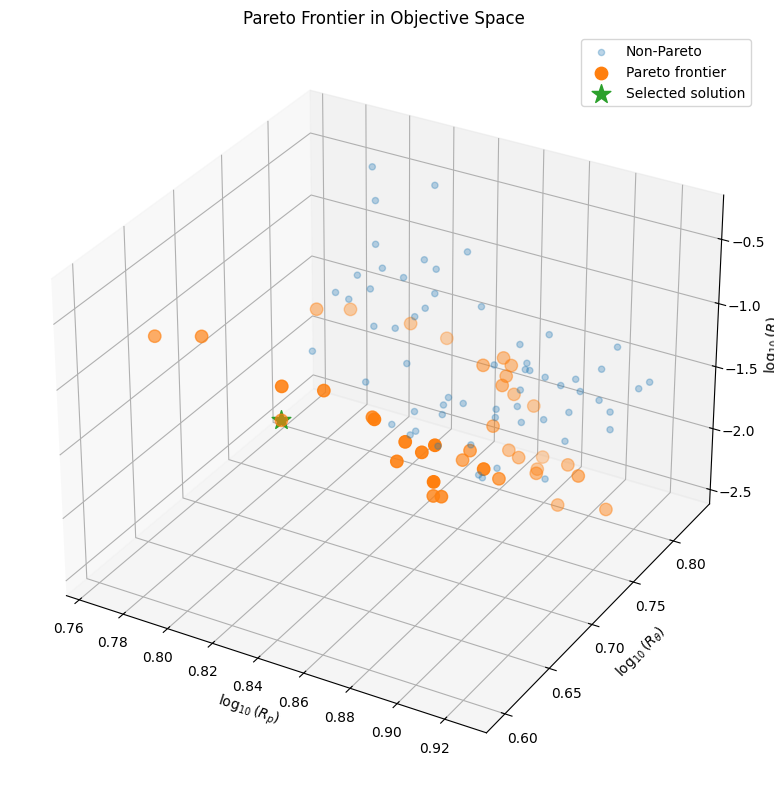

In [24]:
# %%
# ------------------------------------------------------------
# 3D Pareto visualization
# ------------------------------------------------------------

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

non_pareto = df[~df["pareto"]]

ax.scatter(
    non_pareto["log_R_p"],
    non_pareto["log_R_theta"],
    non_pareto["log_R"],
    alpha=0.3,
    label="Non-Pareto"
)

ax.scatter(
    pareto_df["log_R_p"],
    pareto_df["log_R_theta"],
    pareto_df["log_R"],
    s=80,
    label="Pareto frontier"
)

ax.scatter(
    best_row["log_R_p"],
    best_row["log_R_theta"],
    best_row["log_R"],
    s=200,
    marker="*",
    label="Selected solution"
)

ax.set_xlabel(r"$\log_{10}(R_p)$")
ax.set_ylabel(r"$\log_{10}(R_\theta)$")
ax.set_zlabel(r"$\log_{10}(R)$")

ax.set_title(
    "Pareto Frontier in Objective Space"
)

ax.legend()

plt.tight_layout()
plt.show()

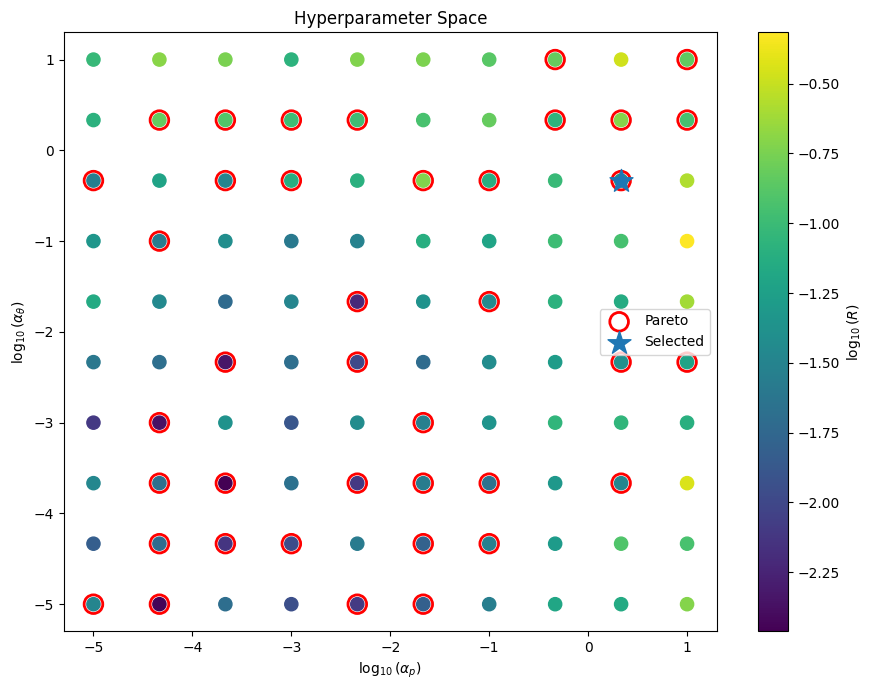

In [25]:
# %%
# ------------------------------------------------------------
# 2D hyperparameter map
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 7)
)

scatter = ax.scatter(
    df["log_alpha_p"],
    df["log_alpha_theta"],
    c=df["log_R"],
    s=90,
    cmap="viridis",
)

ax.scatter(
    pareto_df["log_alpha_p"],
    pareto_df["log_alpha_theta"],
    s=180,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="Pareto"
)

ax.scatter(
    best_row["log_alpha_p"],
    best_row["log_alpha_theta"],
    s=300,
    marker="*",
    label="Selected"
)

ax.set_xlabel(
    r"$\log_{10}(\alpha_p)$"
)

ax.set_ylabel(
    r"$\log_{10}(\alpha_\theta)$"
)

ax.set_title(
    "Hyperparameter Space"
)

cbar = plt.colorbar(scatter)

cbar.set_label(
    r"$\log_{10}(R)$"
)

ax.legend()

plt.tight_layout()
plt.show()

In [37]:
# %%
# ------------------------------------------------------------
# Generate LaTeX table
# ------------------------------------------------------------

columns = [
    "log_alpha_p",
    "log_alpha_theta",
    "log_R",
    "log_R_theta",
    "log_R_p",
    "log_J",
    "stability",
    "robust_score",
]

latex_rows = []

for idx, row in neighbors.iterrows():

    values = [
        f"{row[col]:.6f}"
        for col in columns
    ]

    line = " & ".join(values) + r" \\"

    if idx == best_index:

        values_bold = [
            rf"\textbf{{{row[col]:.6f}}}"
            for col in columns
        ]

        line = (
            " & ".join(values_bold)
            + r" \\"
        )

    latex_rows.append(line)

latex_table = rf"""
\begin{{table}}
\centering

\caption{{
Pareto-optimal solutions around the selected robust optimum.
The highlighted row corresponds to the final selected
hyperparameter pair based on the combined criterion involving
misfit, regularization, and local parameter stability.
}}

\label{{tab:pareto_optimum}}

\resizebox{{\linewidth}}{{!}}{{
\begin{{tabular}}{{cccccccc}}
\hline

$\log \alpha_{{p}}$
&
$\log \alpha_{{\theta}}$
&
$\log R$
&
$\log R_{{\theta}}$
&
$\log R_{{p}}$
&
$\log J$
&
Stability
&
Score
\\

\hline

{chr(10).join(latex_rows)}

\hline
\end{{tabular}}
}}

\end{{table}}
"""

print(latex_table)


\begin{table}
\centering

\caption{
Pareto-optimal solutions around the selected robust optimum.
The highlighted row corresponds to the final selected
hyperparameter pair based on the combined criterion involving
misfit, regularization, and local parameter stability.
}

\label{tab:pareto_optimum}

\resizebox{\linewidth}{!}{
\begin{tabular}{cccccccc}
\hline

$\log \alpha_{p}$
&
$\log \alpha_{\theta}$
&
$\log R$
&
$\log R_{\theta}$
&
$\log R_{p}$
&
$\log J$
&
Stability
&
Score
\\

\hline

-1.000000 & -0.333333 & -1.120880 & 0.621211 & 0.883406 & 0.444138 & 2.729524 & 0.301555 \\
-0.333333 & 0.333333 & -1.067753 & 0.648389 & 0.862266 & 1.115729 & 3.598055 & 0.290228 \\
-0.333333 & 1.000000 & -0.824840 & 0.630543 & 0.848843 & 1.664061 & 4.187300 & 0.406738 \\
\textbf{0.333333} & \textbf{-0.333333} & \textbf{-1.409670} & \textbf{0.661595} & \textbf{0.817111} & \textbf{1.212405} & \textbf{2.602822} & \textbf{0.148590} \\
0.333333 & 0.333333 & -0.706957 & 0.608957 & 0.839939 & 1.377580 & 3.0

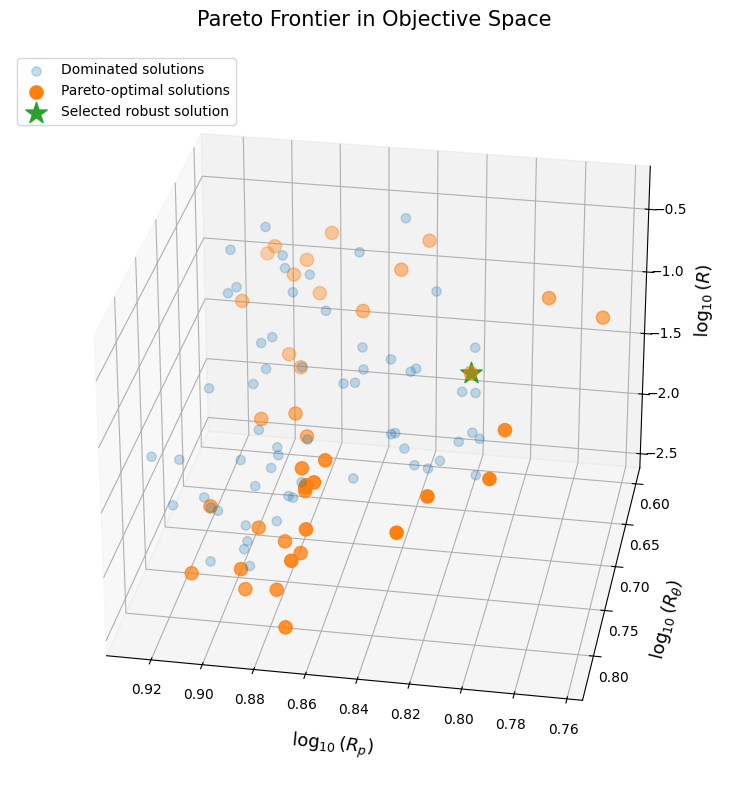

In [34]:
# %%
# ------------------------------------------------------------
# Pareto frontier in objective space
# ------------------------------------------------------------

fig = plt.figure(figsize=(20, 8))

ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# Non-Pareto solutions
# ------------------------------------------------------------

non_pareto = df[~df["pareto"]]

scatter_nonpareto = ax.scatter(
    non_pareto["log_R_p"],
    non_pareto["log_R_theta"],
    non_pareto["log_R"],
    s=45,
    alpha=0.25,
    label="Dominated solutions"
)

# ------------------------------------------------------------
# Pareto-optimal solutions
# ------------------------------------------------------------

scatter_pareto = ax.scatter(
    pareto_df["log_R_p"],
    pareto_df["log_R_theta"],
    pareto_df["log_R"],
    s=90,
    label="Pareto-optimal solutions"
)

# ------------------------------------------------------------
# Selected robust solution
# ------------------------------------------------------------

selected = best_row

ax.scatter(
    selected["log_R_p"],
    selected["log_R_theta"],
    selected["log_R"],
    s=260,
    marker="*",
    label="Selected robust solution"
)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    r"$\log_{10}(R_{p})$",
    fontsize=13,
    labelpad=12
)

ax.set_ylabel(
    r"$\log_{10}(R_{\theta})$",
    fontsize=13,
    labelpad=12
)

ax.set_zlabel(
    r"$\log_{10}(R)$",
    fontsize=13,
    labelpad=12
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Pareto Frontier in Objective Space",
    fontsize=15,
    pad=18
)

# ------------------------------------------------------------
# View angle
# ------------------------------------------------------------

ax.view_init(
    elev=28,
    azim=100
)

# ------------------------------------------------------------
# Grid and legend
# ------------------------------------------------------------

ax.grid(True)

ax.legend(
    loc="upper left",
    fontsize=10
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    "pareto_surface.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()